<a href="https://colab.research.google.com/github/serjtankian/practica-keepcoding-NLP-Search/blob/main/Analisis_de_Sentimiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


ruta_real = '/content/drive/MyDrive/electronics_preprocessed.csv'

df = pd.read_csv(ruta_real)
df = df.dropna(subset=['text_clean', 'sentiment_label']).reset_index(drop=True)

print(df.shape)
print(df[['text_clean', 'sentiment_label']].head())

(4982, 13)
                                          text_clean  sentiment_label
0  try box tower sound like music box try magnepa...                1
1  order wife read negative review picture qualit...                1
2  sound quality unit phenomenal   bose sounddock...                1
3  good keep cpu cool down't forget download cors...                1
4  price right work like ask mount directly ceili...                1


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    df['text_clean'],
    df['sentiment_label'],
    train_size=0.75,
    test_size=0.25,
    random_state=42,
    shuffle=True
)

In [ ]:


cv = TfidfVectorizer(
    max_df=0.95,
    min_df=3,
    max_features=2500,
    strip_accents='ascii',
    ngram_range=(1, 1)
)

cv.fit(X_train)

X_train_ = cv.transform(X_train)
X_test_ = cv.transform(X_test)

Accuracy for C=0.01: 0.8154093097913323
C=0.01 | Train Accuracy=0.8025 | Test Accuracy=0.8154
Accuracy for C=0.05: 0.8154093097913323
C=0.05 | Train Accuracy=0.8025 | Test Accuracy=0.8154
Accuracy for C=0.25: 0.8154093097913323
C=0.25 | Train Accuracy=0.8065 | Test Accuracy=0.8154
Accuracy for C=0.5: 0.8218298555377207
C=0.5 | Train Accuracy=0.8271 | Test Accuracy=0.8218
Accuracy for C=1: 0.8378812199036918
C=1 | Train Accuracy=0.8581 | Test Accuracy=0.8379
Accuracy for C=10: 0.8475120385232745
C=10 | Train Accuracy=0.9540 | Test Accuracy=0.8475
Accuracy for C=100: 0.8146067415730337
C=100 | Train Accuracy=0.9992 | Test Accuracy=0.8146
Accuracy for C=1000: 0.8226324237560193
C=1000 | Train Accuracy=1.0000 | Test Accuracy=0.8226
Accuracy for C=10000: 0.819422150882825
C=10000 | Train Accuracy=1.0000 | Test Accuracy=0.8194


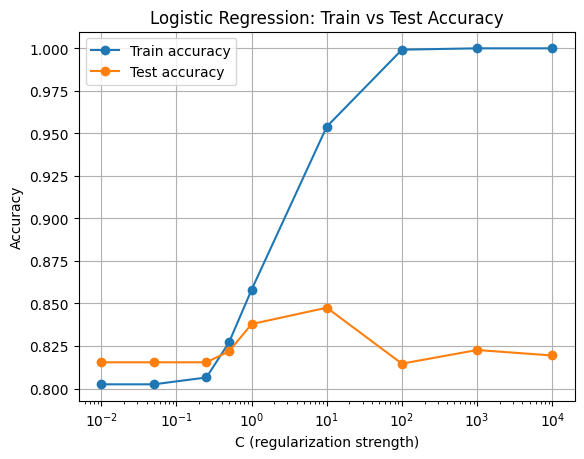

LogisticRegression(C=10, max_iter=500)

In [ ]:

c_params = [0.01, 0.05, 0.25, 0.5, 1, 10, 100, 1000, 10000]

train_acc = []
test_acc = []

for c in c_params:
    lr = LogisticRegression(C=c, solver='lbfgs', max_iter=500)
    lr.fit(X_train_, y_train)

    train_predict = lr.predict(X_train_)
    test_predict = lr.predict(X_test_)

    print("Accuracy for C={}: {}".format(c, accuracy_score(y_test, test_predict)))
    print(
    f"C={c} | Train Accuracy={accuracy_score(y_train, train_predict):.4f} | Test Accuracy={accuracy_score(y_test, test_predict):.4f}"
)

    train_acc.append(accuracy_score(y_train, train_predict))
    test_acc.append(accuracy_score(y_test, test_predict))

plt.plot(
    c_params,
    train_acc,
    marker='o',
    label='Train accuracy'
)

plt.plot(
    c_params,
    test_acc,
    marker='o',
    label='Test accuracy'
)

plt.xscale('log')

plt.xlabel("C (regularization strength)")
plt.ylabel("Accuracy")

plt.title("Logistic Regression: Train vs Test Accuracy")

plt.legend()
plt.grid(True)

plt.show()

best_c = c_params[np.argmax(test_acc)]
lr_final = LogisticRegression(C=best_c, solver='lbfgs', max_iter=500)
lr_final.fit(X_train_, y_train)

In [ ]:

def classify_gboost(X_train, X_test, y_train, y_test):
    clf = GradientBoostingClassifier(
        n_estimators=32,
        learning_rate=1.0,
        max_depth=1,
        random_state=42
    )
    clf.fit(X_train, y_train)

    print("[{}] Accuracy: train = {}, test = {}".format(
        clf.__class__.__name__,
        clf.score(X_train, y_train),
        clf.score(X_test, y_test)
    ))

    return clf

gb_final = classify_gboost(X_train_, X_test_, y_train, y_test)

[GradientBoostingClassifier] Accuracy: train = 0.8538543897216274, test = 0.812199036918138


In [ ]:


joblib.dump(lr_final, '/content/drive/MyDrive/lr_final.pkl')
joblib.dump(gb_final, '/content/drive/MyDrive/gb_final.pkl')
joblib.dump(cv, '/content/drive/MyDrive/tfidf_vectorizer.pkl')
joblib.dump(X_test_, '/content/drive/MyDrive/X_test.pkl')
joblib.dump(y_test, '/content/drive/MyDrive/y_test.pkl')

print("Modelos y datos guardados correctamente.")

Modelos y datos guardados correctamente.


Observaciones:


*   Para el modelado se eligen dos modelos. Uno de regresion  y el otro de GradientBoostingClassifier
*   La regresion presenta signos de overfitting y en test accuracy iguala al otro modelo. En cuanto a train accuracy la regresion presenta el 100 % y el Gradient Boosting 85% de accuracy.

